In [2]:
import os
import sys
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.stats import binned_statistic
from scipy.optimize import curve_fit
import time
import numpy as np
from tqdm import tqdm

In [3]:
#load file
subhalo_file  = r"C:\Users\Mathijs DeKeyser\Documents\TANA\TANA_notebooks\Project\TNG100-1_subhalosCat.hdf5"  # put your group catalog here if available


In [4]:
data = h5py.File(subhalo_file, 'r')
data.keys()


<KeysViewHDF5 ['Config', 'Header', 'Parameters', 'Subhalo']>

In [5]:
#All attributes
print("Header")
for x in list(data['Header'].attrs):
    print(f'The value for {x} is: {data['Header'].attrs[x]}')


print("Parameters")
for x in list(data['Parameters'].attrs):
    print(f'The value for {x} is: {data['Parameters'].attrs[x]}')

print("Subhalo")
for x in list(data['Subhalo'].attrs):
    print(f'The value for {x} is: {data['Subhalo'].attrs[x]}')

Header
The value for BoxSize is: 75000.0
The value for HubbleParam is: 0.6774
The value for Nsubgroups_Total is: 4371211
The value for Omega0 is: 0.3089
The value for OmegaLambda is: 0.6911
The value for Redshift is: 2.220446049250313e-16
The value for Time is: 0.9999999999999998
Parameters
The value for AGB_MassTransferOn is: 1
The value for ActivePartFracForNewDomainDecomp is: 0.003
The value for AdaptiveHydroSofteningSpacing is: 1.2
The value for BlackHoleAccretionFactor is: 1.0
The value for BlackHoleCenteringMassMultiplier is: 1000.0
The value for BlackHoleEddingtonFactor is: 1.0
The value for BlackHoleFeedbackFactor is: 0.1
The value for BlackHoleMaxAccretionRadius is: 1e+20
The value for BlackHoleRadiativeEfficiency is: 0.2
The value for BoxSize is: 75000.0
The value for CellMaxAngleFactor is: 2.25
The value for CellShapingSpeed is: 0.5
The value for ComovingIntegrationOn is: 1
The value for CoolingOn is: 1
The value for CoolingTablePath is: b'L75TNG_Arepo_GFM_Tables/Cooling/coo

In [6]:
#information on subhalos

for el in list(data['Subhalo'].keys()):
    print(f"The value of {el} is: {data['Subhalo'][el]}")

The value of SubhaloBHMass is: <HDF5 dataset "SubhaloBHMass": shape (4371211,), type "<f4">
The value of SubhaloBHMdot is: <HDF5 dataset "SubhaloBHMdot": shape (4371211,), type "<f4">
The value of SubhaloBfldDisk is: <HDF5 dataset "SubhaloBfldDisk": shape (4371211,), type "<f4">
The value of SubhaloBfldHalo is: <HDF5 dataset "SubhaloBfldHalo": shape (4371211,), type "<f4">
The value of SubhaloCM is: <HDF5 dataset "SubhaloCM": shape (4371211, 3), type "<f4">
The value of SubhaloFlag is: <HDF5 dataset "SubhaloFlag": shape (4371211,), type "|b1">
The value of SubhaloGasMetalFractions is: <HDF5 dataset "SubhaloGasMetalFractions": shape (4371211, 10), type "<f4">
The value of SubhaloGasMetalFractionsHalfRad is: <HDF5 dataset "SubhaloGasMetalFractionsHalfRad": shape (4371211, 10), type "<f4">
The value of SubhaloGasMetalFractionsMaxRad is: <HDF5 dataset "SubhaloGasMetalFractionsMaxRad": shape (4371211, 10), type "<f4">
The value of SubhaloGasMetalFractionsSfr is: <HDF5 dataset "SubhaloGasMet

In [7]:
#extract useful data
h = data['Header'].attrs['HubbleParam']
boxsize = data['Header'].attrs['BoxSize']/h
positions = data['Subhalo']['SubhaloPos']/h #kpc most bound particle
COM = data['Subhalo']['SubhaloCM']/h
total_mass_type = data['Subhalo']["SubhaloMassType"][:]*10**10/h # Total Mass of all bound particles per type
total_mass  = data['Subhalo']["SubhaloMass"][:]*10**10/h  #Total mass of all particles all types combined
subhalo_len = data['Subhalo']["SubhaloLen"][:] #Total number of member particle/cells in this Subhalo, of all types.


In [ ]:
from numba import njit, prange

@njit(parallel=True, fastmath=True)
def count_pairs(x, y, z, bins):
    n = x.size
    nbins = bins.size - 1
    counts = np.zeros(nbins, dtype=np.int64)

    for i in prange(n):
        xi, yi, zi = x[i], y[i], z[i]
        for j in range(i+1, n):
            dx = x[j] - xi
            dy = y[j] - yi
            dz = z[j] - zi
            r2 = dx*dx + dy*dy + dz*dz
            r = np.sqrt(r2)

            # search bin for r
            b = np.searchsorted(bins, r) - 1
            counts[b] += 1
    return counts

def two_point_corrfunc(positions, rbins, boxsize, chunk_size=200_000):
    """
    Wrapper around count_pairs with chunking for large data.
    Periodic wrapping is applied before chunking.
    """

    # Unpack positions
    x = positions[:,0].copy()
    y = positions[:,1].copy()
    z = positions[:,2].copy()

    # Apply periodic wrapping 
    x %= boxsize
    y %= boxsize
    z %= boxsize

    N = len(x)
    nbins = len(rbins)-1
    total = np.zeros(nbins, dtype=np.int64)

    for start in tqdm(range(0, N, chunk_size), desc="Chunks"):
        end = min(start+chunk_size, N)

        x_chunk = x[start:end]
        y_chunk = y[start:end]
        z_chunk = z[start:end]

        total += count_pairs(x_chunk, y_chunk, z_chunk, rbins)

    return total



def two_point_natural(positions, boxsize, rbins, use_jackknife=True, n_jack=8, verbose=False):
    """
    Compute the two-point correlation function using the natural estimator:
        xi(r) = DD(r) / RR(r) - 1
    where RR(r) is analytically computed assuming a uniform random distribution in the box:
        RR_shell = total_pairs * (V_shell / V_box)
    - positions: (N,3)
    - boxsize: scalar (periodic!!!)
    - rbins: radial bin edges
    Returns xi, DD_counts, RR_counts, jackknife covariance if requested.
    """
    N = positions.shape[0]
    t0=time.time()
    DD_counts = two_point_corrfunc(positions, rbins, boxsize)
    t1=time.time()
    print("Pair counting time: %.2f s" % (t1-t0))

    # analytic RR
    Vbox = boxsize**3
    shell_vol = 4.0/3.0*np.pi*(rbins[1:]**3 - rbins[:-1]**3)
    total_pairs = N*(N-1)/2.0
    RR_counts = total_pairs * (shell_vol / Vbox)
    with np.errstate(divide='ignore', invalid='ignore'):
        xi = DD_counts / np.maximum(RR_counts, 1e-12) - 1.0

    result = dict(xi=xi, DD=DD_counts, RR=RR_counts, rbins=rbins)
    # jackknife errors: partition box into n_jack^3 subcubes and delete-one JK
    if use_jackknife:
        print("Computing jackknife resamples...")
        # partition indices along coordinates
        nsub = int(round(n_jack**(1/3))) if isinstance(n_jack, int) and n_jack>1 else 2
        # simpler: divide box into nsub^3 equal cubes
        if nsub < 2:
            nsub = 2
        # get assigned cell index for each particle
        cell_coords = np.floor((positions / boxsize) * nsub).astype(int) % nsub
        cell_id = cell_coords[:,0] + nsub*cell_coords[:,1] + nsub*nsub*cell_coords[:,2]
        unique_cells = np.arange(nsub**3)
        jk_xi = np.zeros((nsub**3, len(rbins)-1))
        for i, cell in enumerate(unique_cells):
            # exclude particles in this cell
            mask = cell_id != cell
            pos_sub = positions[mask]
            dd = two_point_corrfunc(pos_sub, rbins, boxsize)
            Nsub = pos_sub.shape[0]
            totpairs_sub = Nsub*(Nsub-1)/2.0
            RR_sub = totpairs_sub * (shell_vol / Vbox)
            xi_sub = dd / np.maximum(RR_sub, 1e-12) - 1.0
            jk_xi[i] = xi_sub
        # jackknife covariance and std
        mean_jk = np.mean(jk_xi, axis=0)
        cov_jk = (nsub**3 - 1)/ (nsub**3) * np.dot((jk_xi - mean_jk).T, (jk_xi - mean_jk))
        err_jk = np.sqrt(np.diag(cov_jk))
        result.update(dict(jk_cov=cov_jk, jk_err=err_jk))
    return result




In [ ]:
#Calculate correlation function

# radius bins for clustering
rmin = 0.01 * boxsize
rmax = 0.2 * boxsize #Distances up to 0.5 are physical, beyond 0.2 becomes noisy and large variance
nbins = 20
#logbins
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins)
xires = two_point_natural(positions, boxsize, rbins, use_jackknife=False, n_jack=27, verbose=True)
# plot xi with jackknife errors if present
rmid = np.sqrt(rbins[1:] * rbins[:-1])

Chunks: 100%|██████████| 22/22 [1:03:30<00:00, 173.20s/it]

Pair counting time: 3810.92 s


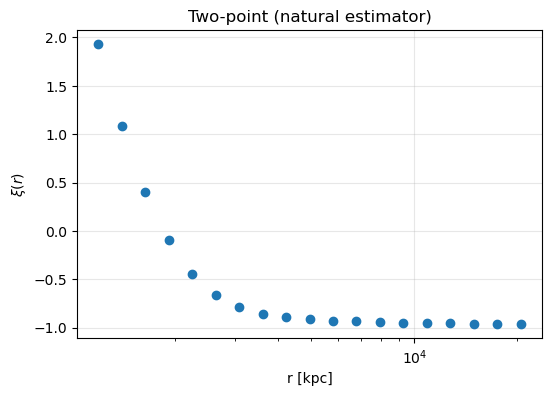

In [12]:
plt.figure(figsize=(6,4))
plt.errorbar(rmid, xires["xi"], yerr=xires.get("jk_err", None), fmt='o')
plt.xscale('log'); plt.yscale('linear')
plt.xlabel("r [kpc]"); plt.ylabel(r"$\xi(r)$"); plt.title("Two-point (natural estimator)")
plt.grid(alpha=0.3); plt.show()

In [ ]:
# Stellar-to-halo mass 
Mtot = total_mass
Mstar = total_mass_type[:,4] 

# compute baryon fraction f_b = (Mgas + Mstar)/Mtot for each subhalo
Mgas = total_mass_type[:,0]
fb = (Mgas + Mstar) / np.maximum(Mtot, 1e-30)
mask = (Mstar > 0) & (Mtot > 0)

# basic statistics: median relation in bins + bootstrap errors
nb = 12
bins = np.logspace(np.log10(np.min(Mtot[mask])), np.log10(np.max(Mtot[mask])), nb+1)
digit = np.digitize(Mtot[mask], bins) - 1
med = np.zeros(nb)
p16 = np.zeros(nb); p84 = np.zeros(nb)
for i in range(nb):
    sel = digit == i
    if np.sum(sel) > 0:
        med[i] = np.median(Mstar[mask][sel] / Mtot[mask][sel])
        p16[i] = np.percentile(Mstar[mask][sel] / Mtot[mask][sel], 16)
        p84[i] = np.percentile(Mstar[mask][sel] / Mtot[mask][sel], 84)
    else:
        med[i] = np.nan; p16[i] = np.nan; p84[i] = np.nan
mid = np.sqrt(bins[:-1]*bins[1:])
# plot SMHM
plt.figure(figsize=(6,4))
plt.loglog(Mtot[mask], Mstar[mask], '.', ms=2)
plt.xlabel(r"Halo mass ($M_\odot$) "); plt.ylabel(r"Stellar mass ($M_\odot)")
plt.title("Stellar-to-halo mass")
plt.grid(alpha=0.3); plt.show()

# baryon fraction plot
plt.figure(figsize=(6,4))
plt.semilogx(Mtot[mask], fb[mask], '.', ms=2)
plt.xlabel("Halo mass"); plt.ylabel("baryon fraction (Mgas+Mstar)/Mtot")
plt.title("Baryon fraction vs halo mass")
plt.grid(alpha=0.3); plt.show()

#Plot errors
plt.errorbar(mid, med, yerr=[med-p16, p84-med], fmt='o')
plt.xscale('log'); plt.xlabel("Mhalo"); plt.ylabel("Mstar/Mhalo"); plt.title("Median baryon fraction (binned)")
plt.grid(alpha=0.3); plt.show()
